# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [2]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
!pip uninstall -y pycaret
!pip install pycaret==3.3.2

Found existing installation: pycaret 3.3.2
Uninstalling pycaret-3.3.2:
  Successfully uninstalled pycaret-3.3.2
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
Using cached pycaret-3.3.2-py3-none-any.whl (486 kB)


In [5]:
import sys

# Temporarily remove the explicit Python version check in pycaret/__init__.py
# This is a workaround for PyCaret 3.x not officially supporting Python 3.12 yet.
init_file_path = '/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py'

with open(init_file_path, 'r') as f:
    content = f.read()

# Pattern for Python 3.12 incompatibility check
# This needs to cover the entire block, including multi-line arguments
pattern_312 = """elif sys.version_info >= (3, 12):
    raise RuntimeError(
        "Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ",
        sys.version_info,
        "Please DOWNGRADE your Python version.",
    )"""

# Replace the block with a commented version to preserve structure and disable the check
if pattern_312 in content:
    commented_pattern = "\n".join([f"# {line}" for line in pattern_312.splitlines()])
    content = content.replace(pattern_312, commented_pattern)
    print("Python 3.12 version check in PyCaret __init__.py commented out.")
else:
    print("Python 3.12 version check pattern not found in PyCaret __init__.py. (Already patched or different version)")

# Also check for older Python version incompatibility (if any) and comment it out
pattern_old_py = """if sys.version_info < (3, 9):
    raise RuntimeError(
        "Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ",
        sys.version_info,
        "Please UPGRADE your Python version.",
    )"""
if pattern_old_py in content:
    commented_old_py_pattern = "\n".join([f"# {line}" for line in pattern_old_py.splitlines()])
    content = content.replace(pattern_old_py, commented_old_py_pattern)
    print("Older Python version check in PyCaret __init__.py commented out.")


with open(init_file_path, 'w') as f:
    f.write(content)

print("PyCaret __init__.py patching complete.")

Python 3.12 version check in PyCaret __init__.py commented out.
Older Python version check in PyCaret __init__.py commented out.
PyCaret __init__.py patching complete.


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

In [6]:
#First experiment
df_exp1 = penguins[['flipper_length_mm', 'bill_length_mm', 'species']]
df_exp1 = df_exp1.dropna()
df_exp1.head()

,flipper_length_mm,bill_length_mm,species
0,181.0,39.1,Adelie
1,186.0,39.5,Adelie
2,195.0,40.3,Adelie
4,193.0,36.7,Adelie
5,190.0,39.3,Adelie


,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(342, 3)"
5,Transformed data shape,"(342, 3)"
6,Transformed train set shape,"(239, 3)"
7,Transformed test set shape,"(103, 3)"
8,Numeric features,2
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9411,0.9924,0.9411,0.9480,0.9405,0.9076,0.9112,0.9210


Processing:   0%|          | 0/9 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9806,0.9992,0.9806,0.9808,0.9805,0.9695,0.9697


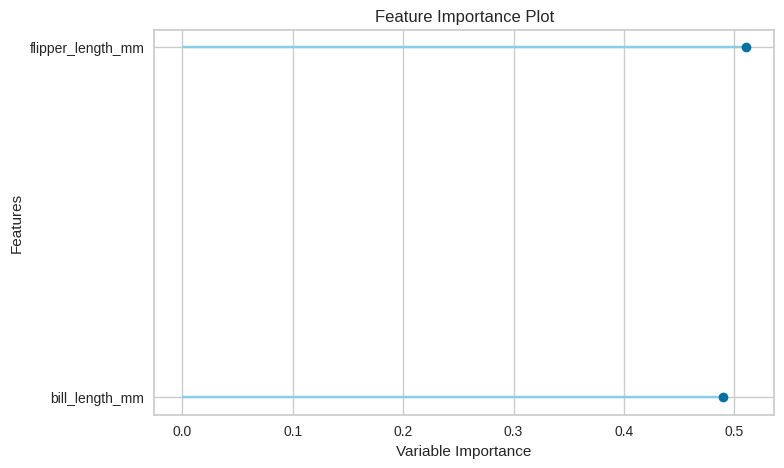

In [7]:
from pycaret.classification import *

exp1 = setup(
    data=df_exp1,
    target='species',
    session_id=123,
    normalize=True,
    transformation=True
)
best_model_exp1 = compare_models(include=['rf'])
evaluate_model(best_model_exp1)
predictions_exp1 = predict_model(best_model_exp1)
predictions_exp1.head()
plot_model(best_model_exp1, plot='feature')

In [8]:
#Second
df_exp2 = penguins[['body_mass_g', 'species', 'sex']]

df_exp2 = df_exp2.dropna()

df_exp2.head()

,body_mass_g,species,sex
0,3750.0,Adelie,Male
1,3800.0,Adelie,Female
2,3250.0,Adelie,Female
4,3450.0,Adelie,Female
5,3650.0,Adelie,Male


,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.6806,0.7420,0.6806,0.6917,0.6720,0.3630,0.3726,0.3110


Processing:   0%|          | 0/9 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.4600,0.4400,0.4600,0.4583,0.4545,-0.0800,-0.0816


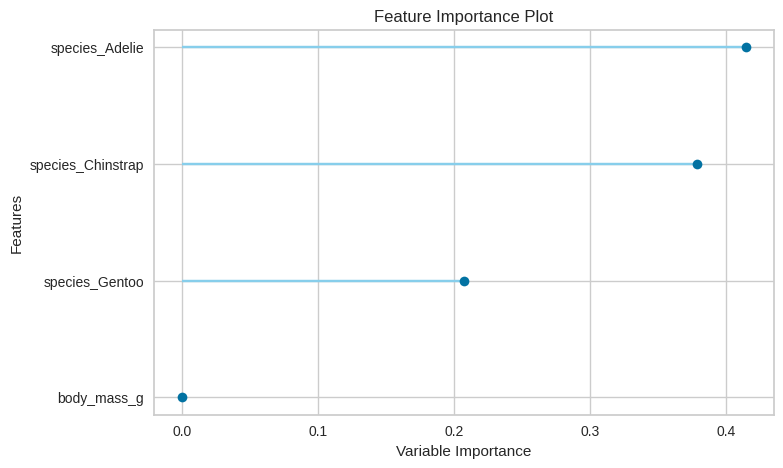

In [9]:
from pycaret.classification import *

exp2 = setup(
    data=df_exp2,
    target='sex',
    session_id=123,
    normalize=True,
    transformation=True
)
best_model_exp2 = compare_models(include=['rf'])
evaluate_model(best_model_exp2)
predictions_exp2 = predict_model(best_model_exp2)
predictions_exp2.head()
plot_model(best_model_exp2, plot='feature')

In [10]:
#Third
penguins['target'] = penguins['sex'] + "_" + penguins['species']

In [11]:
df_exp3 = penguins[['island', 'bill_length_mm', 'bill_depth_mm',
              'flipper_length_mm', 'body_mass_g', 'sex', 'species']]

df_exp3 = df_exp3.dropna()

df_exp3['target'] = df_exp3['sex'] + "_" + df_exp3['species']

df_exp3 = df_exp3.drop(['sex', 'species'], axis=1)

df_exp3.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,target
0,Torgersen,39.1,18.7,181.0,3750.0,Male_Adelie
1,Torgersen,39.5,17.4,186.0,3800.0,Female_Adelie
2,Torgersen,40.3,18.0,195.0,3250.0,Female_Adelie
4,Torgersen,36.7,19.3,193.0,3450.0,Female_Adelie
5,Torgersen,39.3,20.6,190.0,3650.0,Male_Adelie


,Description,Value
0,Session id,123
1,Target,target
2,Target type,Multiclass
3,Target mapping,"Female_Adelie: 0, Female_Chinstrap: 1, Female_Gentoo: 2, Male_Adelie: 3, Male_Chinstrap: 4, Male_Gentoo: 5"
4,Original data shape,"(333, 6)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Numeric features,4
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8583,0.9821,0.8583,0.8723,0.8550,0.8267,0.8296,0.4360


Processing:   0%|          | 0/9 [00:00<?, ?it/s]

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8500,0.9806,0.8500,0.8588,0.8503,0.8173,0.8185


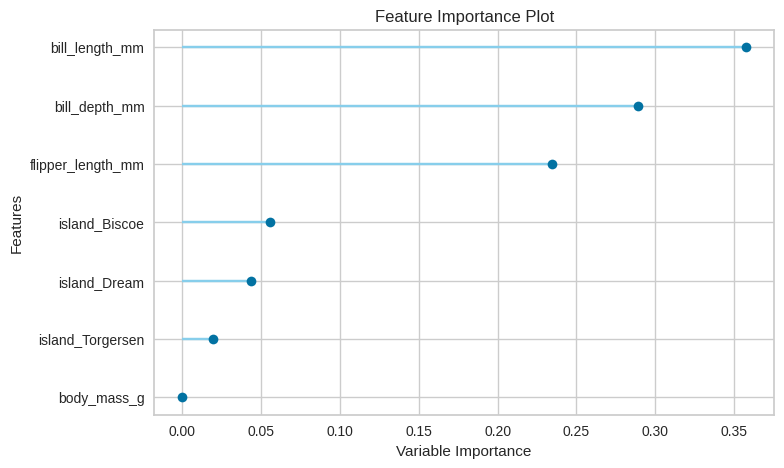

In [12]:
from pycaret.classification import *

exp3 = setup(
    data=df_exp3,
    target='target',
    session_id=123,
    normalize=True,
    transformation=True
)
best_model_exp3 = compare_models(include=['rf'])
evaluate_model(best_model_exp3)
predictions_exp3 = predict_model(best_model_exp3)
predictions_exp3.head()
plot_model(best_model_exp3, plot='feature')